In [42]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

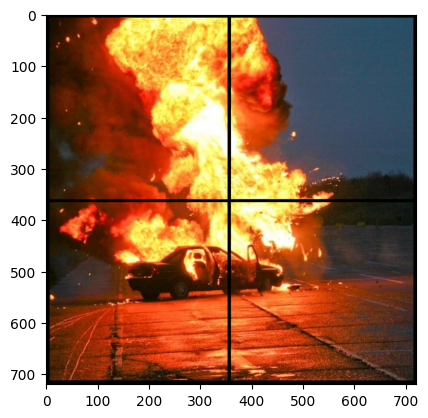

In [43]:
img = plt.imread('Assets/Meledak.png')
plt.imshow(img)

In [44]:
def fungsi_empat_S(gambar, a, b, mode='H'):
 return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

In [45]:
def fungsi_tiga(image, p1=0, p2=0, p3=0, p4=0):
    h, w = image.shape
    dilated = np.zeros((h * 2, w * 2)).astype(int)
    for y in range(h * 2):
        for x in range(w * 2):
            dilated[y][x] = image[int(y / 2)][int(x / 2)]
    
    sy, ey = max(0, p1), min(h * 2, h * 2 - p2)
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4)
    
    hasil = dilated[sy:ey, sx:ex]
    
    return hasil

In [46]:
def crop_hitam(image):
    if image.dtype == float or image.dtype == np.float32:
        image = np.clip(image, 0, 255).astype(np.uint8)
    
    if image.ndim == 3:
        mask = np.any(image > 0, axis=2)
    else:
        mask = image > 0
    
    baris = np.any(mask, axis=1)
    kolom = np.any(mask, axis=0)
    
    if not np.any(baris) or not np.any(kolom):
        return image
    
    y1, y2 = np.where(baris)[0][[0, -1]]
    x1, x2 = np.where(kolom)[0][[0, -1]]
    return image[y1:y2+1, x1:x2+1]

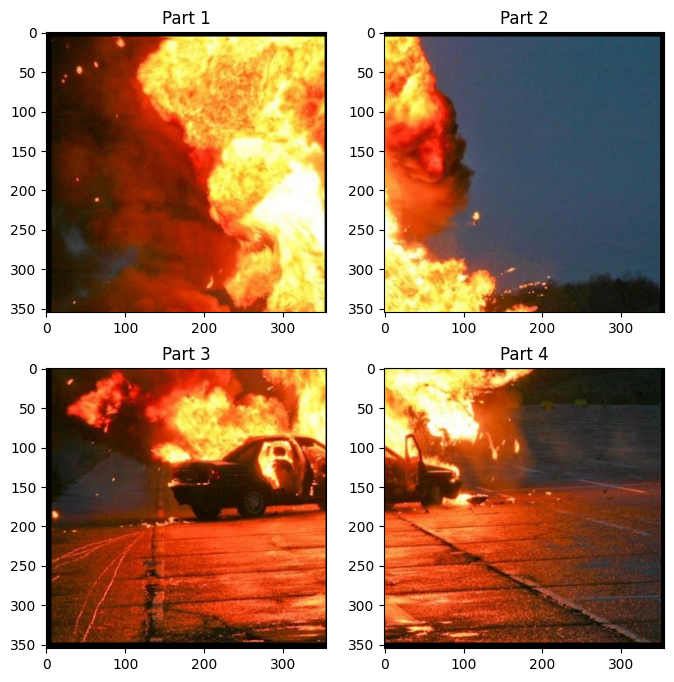

In [ ]:
bagian_atas = fungsi_empat_S(img, 0, 355, mode='H')
bagian_bawah = fungsi_empat_S(img, 365, 730, mode='H')

citra_1 = fungsi_empat_S(bagian_atas, 0, 355, mode='V')
citra_2 = fungsi_empat_S(bagian_atas, 365, 730, mode='V')

citra_3 = fungsi_empat_S(bagian_bawah, 0, 355, mode='V')
citra_4 = fungsi_empat_S(bagian_bawah, 365, 730, mode='V') 


plt.figure(figsize=(8, 8))

# Gambar 1 (Posisi kiri atas)
plt.subplot(2, 2, 1)
plt.title("Part 1")
plt.imshow(citra_1)

# Gambar 2 (Posisi kanan atas)
plt.subplot(2, 2, 2)
plt.title("Part 2")
plt.imshow(citra_2)

# Gambar 3 (Posisi kiri bawah)
plt.subplot(2, 2, 3)
plt.title("Part 3")
plt.imshow(citra_3)

# Gambar 4 (Posisi kanan bawah)
plt.subplot(2, 2, 4)
plt.title("Part 4")
plt.imshow(citra_4)